In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/used-car-dataset-ford-and-mercedes/cclass.csv
/kaggle/input/used-car-dataset-ford-and-mercedes/unclean cclass.csv
/kaggle/input/used-car-dataset-ford-and-mercedes/focus.csv
/kaggle/input/used-car-dataset-ford-and-mercedes/audi.csv
/kaggle/input/used-car-dataset-ford-and-mercedes/toyota.csv
/kaggle/input/used-car-dataset-ford-and-mercedes/skoda.csv
/kaggle/input/used-car-dataset-ford-and-mercedes/ford.csv
/kaggle/input/used-car-dataset-ford-and-mercedes/vauxhall.csv
/kaggle/input/used-car-dataset-ford-and-mercedes/bmw.csv
/kaggle/input/used-car-dataset-ford-and-mercedes/vw.csv
/kaggle/input/used-car-dataset-ford-and-mercedes/hyundi.csv
/kaggle/input/used-car-dataset-ford-and-mercedes/unclean focus.csv
/kaggle/input/used-car-dataset-ford-and-mercedes/merc.csv


In [ ]:
cclass = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/cclass.csv')
focus = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/focus.csv')
ford = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/ford.csv')
bmw = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/bmw.csv')
audi = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/audi.csv')
hyundi = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/hyundi.csv')
merc = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/merc.csv')
skoda = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/skoda.csv')
toyota = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/toyota.csv')
vauxhall = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/vauxhall.csv')
vw = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/vw.csv')

uncln_c = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/unclean cclass.csv')
uncln_f = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/unclean focus.csv')


In [ ]:
lst = [cclass,focus,ford,bmw,audi,hyundi, merc,skoda,toyota,vauxhall,vw, uncln_c, uncln_f]

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
for i in lst:
    i.info()

In [ ]:

sns.heatmap(uncln_c.isnull())


In [ ]:
sns.heatmap(uncln_f.isnull())

# Clean the data (just for exo)

In [ ]:
cls = ["price","mileage","engine size","mileage2","engine size2"]
for c in cls:
    uncln_c[c] = uncln_c[c].str.replace('£', '').str.replace(',', '')

In [ ]:
uncln_c[cls] = uncln_c[cls].apply(pd.to_numeric, errors='coerce')


In [ ]:
uncln_c.info()

In [ ]:

# Create a new column 'mileage' with the higher value from columns 'mileage' and 'mileage2'
# uncln_c['mileage'] = np.maximum(uncln_c['mileage'], uncln_c['mileage2'])
uncln_c['mileage'] = np.fmax(uncln_c['mileage'], uncln_c['mileage2'])

In [ ]:
uncln_c['engine size'] = np.fmin(uncln_c['engine size'], uncln_c['engine size2'])
uncln_c['engine size'] = round(uncln_c['engine size'], 1)

In [ ]:
uncln_c.loc[~uncln_c['fuel type'].isin(["Diesel", "Petrol", "Hybrid"]), 'fuel type'] = uncln_c['fuel type2']

In [ ]:
uncln_c = uncln_c.drop(["mileage2","fuel type2", "engine size2", "reference"], axis=1)

In [ ]:
uncln_c.isnull().sum()/len(uncln_c)

In [ ]:
uncln_c =  uncln_c.dropna()
uncln_c

# Intergrate the tables

In [ ]:
hyundi= hyundi.rename(columns={'tax(£)': 'tax'})
hyundi.columns

In [ ]:
tbs = [ford,bmw,audi,hyundi, merc,skoda,toyota,vauxhall,vw,cclass, focus]

# Concatenate DataFrames horizontally
dfs = pd.concat(tbs, axis=0)

In [ ]:
dfs.isnull().sum()/len(dfs)

In [ ]:
# dfs['tax'] = dfs['tax'].fillna(dfs.tax.median())
# dfs['mpg'] = dfs['mpg'].fillna(dfs.mpg.median())
# dfs.tail()

In [ ]:
dfs.info()

# EDA

## target analysis

In [ ]:
target = 'price'

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(dfs['price'], bins=40, kde=True)

## feature analysis

In [ ]:
features = dfs.drop(['price'], axis = 1)

In [ ]:
features.columns

In [ ]:
features.describe(include = "all")

In [ ]:
num_cls = features.columns[features.dtypes != 'object']
cat_cls = features.columns[features.dtypes == 'object']
print(num_cls)
print(cat_cls)

## Univariable-Numerical features

In [ ]:
N = len(num_cls)
  
fig = plt.figure(figsize=(18, 5*N ))
    
for i,col in enumerate(num_cls):
    plt.subplot(N,2,1+i)
        
    sns.histplot(features[col],bins=50 , kde = True)
       
    plt.tight_layout()

In [ ]:
dfs.loc[dfs['year'] == 2060, 'year'] = 2006

In [ ]:
dfs.loc[dfs['year']<2000]

## Univariable-Category features

In [ ]:
NC = len(["transmission", "fuelType"])
  
fig = plt.figure(figsize=(15, 5 * NC))
    
for i, col in enumerate(["transmission", "fuelType"]):
    plt.subplot(NC, 2, 1 + i)
        
    sns.countplot(data=dfs, x=col)
        
plt.tight_layout()
plt.show()

## Bivariable-Categorical VS target

In [ ]:
NC = len(["transmission", "fuelType"])
  
fig = plt.figure(figsize=(15, 5 * NC))
    
for i, col in enumerate(["transmission", "fuelType"]):
    plt.subplot(NC, 2, 1 + i)
        
    sns.boxplot(data=dfs, x=col, y='price')
        
plt.tight_layout()
plt.show()

In [ ]:
features.model.unique()

## Keep only the reasonable(price) car

In [ ]:
h = dfs.loc[dfs.price>80000]
h.model.unique()


In [ ]:
car = dfs.loc[dfs.price <=50000, :]

In [ ]:
car.model.nunique()

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(car['price'], bins=40, kde=True)

In [ ]:
car.hist(figsize=(12, 10), bins=40)
plt.tight_layout()
plt.show()

In [ ]:
NC = len(["transmission", "fuelType"])
  
fig = plt.figure(figsize=(15, 5 * NC))
    
for i, col in enumerate(["transmission", "fuelType"]):
    plt.subplot(NC, 2, 1 + i)
        
    sns.boxplot(data=car, x=col, y='price')
        
plt.tight_layout()
plt.show()

In [ ]:
NC = len(["transmission", "fuelType"])
  
fig = plt.figure(figsize=(15, 5 * NC))

for i,col in enumerate(["transmission", "fuelType"]):

    plt.subplot(NC,2,1+i)
    ### ecdf = empirical cumulated density function
    sns.ecdfplot(car, x= 'price', hue=col)
    plt.hlines(0.5,xmin=0,xmax = car['price'].max(), color='grey')
    plt.axis([0,car['price'].max(),0,1.1])
plt.tight_layout()
plt.show()

## Bivariable-Numerical VS target

In [ ]:
N = len(num_cls)

plt.figure(figsize=(15,5*N))
for i,col in enumerate(num_cls):

    plt.subplot(N,2,1+i)
    sns.scatterplot(car, y= 'price', x=col, hue=col)

plt.tight_layout()
plt.show()

## Muitivariable

In [ ]:
car.groupby(["transmission", "fuelType"])['price'].mean()

In [ ]:
import plotly.express as px

fig = px.scatter_3d(car, x='engineSize', y='mileage', z='price',
              color='transmission')
fig.show()

## feature engineering for car models

In [ ]:
# Provided list of car models
car_models = car['model'].unique()

# Extracting car brand
def get_brand(model):
    if model in ['Fiesta', 'Focus', 'Puma', 'Kuga', 'EcoSport', 'C-MAX', 'Mondeo', 'Ka+', 'Tourneo Custom', 'S-MAX', 
                 'B-MAX', 'Edge', 'Tourneo Connect', 'Grand C-MAX', 'KA', 'Galaxy', 'Mustang', 'Grand Tourneo Connect',
                 'Fusion', 'Ranger', 'Streetka', 'Escort', 'Transit Tourneo']:
        return 'Ford'
    elif model in ['5 Series', '6 Series', '1 Series', '7 Series', '2 Series', '4 Series', 'X3', '3 Series', 'X5', 
                   'X4', 'i3', 'X1', 'M4', 'X2', 'X6', '8 Series', 'Z4', 'X7', 'M5', 'i8', 'M2', 'M3', 'M6', 'Z3']:
        return 'BMW'
    elif model in ['A1', 'A6', 'A4', 'A3', 'Q3', 'Q5', 'A5', 'S4', 'Q2', 'A7', 'TT', 'Q7', 'RS6', 'RS3', 'A8', 'Q8', 
                   'RS4', 'RS5', 'R8', 'SQ5', 'S8', 'SQ7', 'S3', 'S5', 'A2', 'RS7']:
        return 'Audi'
    elif model in ['I20', 'Tucson', 'I10', 'IX35', 'I30', 'I40', 'Ioniq', 'Kona', 'Veloster', 'I800', 'IX20', 'Santa Fe', 
                   'Accent', 'Terracan', 'Getz', 'Amica']:
        return 'Hyundai'
    elif model in ['SLK', 'S Class', 'SL CLASS', 'G Class', 'GLE Class', 'GLA Class', 'A Class', 'B Class', 'GLC Class', 
                   'C Class', 'E Class', 'GL Class', 'CLS Class', 'CLC Class', 'CLA Class', 'V Class', 'M Class', 
                   'CL Class', 'GLS Class', 'GLB Class', 'X-CLASS', '180', 'CLK', 'R Class', '230', '220', '200']:
        return 'Mercedes-Benz'
    elif model in ['Octavia', 'Citigo', 'Yeti Outdoor', 'Superb', 'Kodiaq', 'Rapid', 'Karoq', 'Fabia', 'Yeti', 'Scala', 
                   'Roomster', 'Kamiq']:
        return 'Skoda'
    elif model in ['GT86', 'Corolla', 'RAV4', 'Yaris', 'Auris', 'Aygo', 'C-HR', 'Prius', 'Avensis', 'Verso', 'Hilux', 
                   'PROACE VERSO', 'Land Cruiser', 'Supra', 'Camry', 'Verso-S', 'IQ', 'Urban Cruiser']:
        return 'Toyota'
    elif model in ['Corsa', 'Astra', 'Viva', 'Mokka', 'Mokka X', 'Crossland X', 'Zafira', 'Meriva', 'Zafira Tourer', 'Adam', 
                   'Grandland X', 'Antara', 'Insignia', 'Ampera', 'GTC', 'Combo Life', 'Vivaro', 'Cascada', 'Kadjar', 'Agila', 
                   'Tigra', 'Vectra']:
        return 'Vauxhall/Opel'
    elif model in ['T-Roc', 'Golf', 'Passat', 'T-Cross', 'Polo', 'Tiguan', 'Sharan', 'Up', 'Scirocco', 'Beetle', 'Caddy Maxi Life',
                   'Caravelle', 'Touareg', 'Arteon', 'Touran', 'Golf SV', 'Amarok', 'Tiguan Allspace', 'Shuttle', 'Jetta', 'CC', 
                   'California', 'Caddy Life', 'Caddy', 'Caddy Maxi', 'Eos', 'Fox']:
        return 'Volkswagen'
    else:
        return 'Other'

# Car type classification
def get_car_type(model):
    suvs = ['Kuga', 'EcoSport', 'Edge', 'X5', 'X6', 'Q5', 'Q7', 'Tucson', 'Santa Fe', 'RAV4', 'Land Cruiser', 'Hilux', 
            'Grandland X', 'Tiguan', 'Touareg', 'Kodiaq', 'Karoq', 'Kamiq']
    hatchbacks = ['Fiesta', 'Focus', 'Puma', 'A1', 'A3', 'I20', 'I30', 'Polo', 'Golf', 'Yaris', 'Fabia', 'Corsa', 'Astra']
    sedans = ['Mondeo', 'Fusion', '5 Series', '3 Series', 'A4', 'A6', 'C Class', 'E Class', 'Octavia', 'Superb', 'Corolla', 
              'Camry', 'Insignia', 'Passat', 'Arteon']
    performance = ['Mustang', 'M4', 'M2', 'M3', 'M6', 'RS6', 'RS3', 'RS4', 'RS5', 'RS7', 'R8', 'GT86', 'Supra', 'Golf R', 'Scirocco R']
    coupes = ['Z4', 'Z3', 'TT', 'SLK', 'CLK', 'Cascada', 'Eos', 'Beetle']
    vans = ['Tourneo Custom', 'Transit Tourneo', 'Vivaro', 'Caddy', 'Caddy Maxi', 'Shuttle']
    
    if model in suvs:
        return 'SUV'
    elif model in hatchbacks:
        return 'Hatchback'
    elif model in sedans:
        return 'Sedan'
    elif model in performance:
        return 'Performance'
    elif model in coupes:
        return 'Coupe'
    elif model in vans:
        return 'Van'
    else:
        return 'Other'

# High-performance flag
def is_high_performance(model):
    if model in ['M4', 'M5', 'M2', 'M3', 'M6', 'RS6', 'RS3', 'RS4', 'RS5', 'RS7', 'R8', 'GT86', 'Supra',
                ' 8 Series', ' X7', ' X5', ' i8', ' X6', ' 2 Series',' X3', ' X4',' 3 Series', ' Q7', ' Q8', 
                 ' Q5', ' A8', ' I10', ' G Class', ' SL CLASS',' GLC Class', ' S Class', ' GLS Class', ' A Class', ' C Class',
                 ' GLE Class', ' E Class', ' CLS Class', ' Karoq', ' California'
                ]:
        return 1
    else:
        return 0


# model price > 80000
#[' 8 Series', ' M4', ' 2 Series', ' M5', ' Q7', ' Q8', ' R8', ' RS6', ' I10', ' SL CLASS', ' G Class', ' A Class', ' S Class',' GLE Class', ' C Class', ' Karoq']


In [ ]:
car['model'] = car['model'].str.strip()
car['Brand'] = car['model'].apply(get_brand)
car['Car_Type'] = car['model'].apply(get_car_type)
car['High_Performance'] = car['model'].apply(is_high_performance)


In [ ]:
car.head(20)

## New Columns EDA

In [ ]:
NC = len(["Brand", "Car_Type", "High_Performance"])
  
fig = plt.figure(figsize=(15, 5 * NC))
    
for i, col in enumerate(["Brand", "Car_Type", "High_Performance"]):
    plt.subplot(NC, 2, 1 + i)
        
    sns.countplot(data=car, x=col)

    plt.xticks(rotation=90)
        
plt.tight_layout()
plt.show()

In [ ]:
NC = len(["Brand", "Car_Type", "High_Performance"])
  
fig = plt.figure(figsize=(15, 5 * NC))
    
for i, col in enumerate(["Brand", "Car_Type", "High_Performance"]):
    plt.subplot(NC, 2, 1 + i)
        
    sns.boxplot(data=car, x=col, y='price')
    
    plt.xticks(rotation=90)
        
plt.tight_layout()
plt.show()

In [ ]:
car.groupby(["Brand", "Car_Type"])['price'].mean()

## Replace the model column by 3 new columns

In [ ]:
car = car.drop(['model'], axis=1)

## Imputer

In [ ]:
from sklearn.impute import SimpleImputer

# Create SimpleImputer object with 'median' strategy
median_imputer = SimpleImputer(strategy='median')

# Apply SimpleImputer to 'tax' and 'mpg' columns
car['tax'] = median_imputer.fit_transform(car[['tax']])
car['mpg'] = median_imputer.fit_transform(car[['mpg']])

## Encoder

In [ ]:
car.index

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Selecting the categorical columns
c_cls = ["transmission", "fuelType", "Brand", "Car_Type"]

# Initialize OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False)  # drop='first' to avoid multicollinearity

# Fit and transform the categorical columns
encoded_features = encoder.fit_transform(car[c_cls])

# Convert encoded features into a DataFrame with appropriate column names
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(c_cls))

# Reset index to align with the original DataFrame
encoded_df.index = car.index

# Concatenate the encoded columns with the original DataFrame (dropping the original categorical columns)
car_encoded = pd.concat([car.drop(columns=c_cls), encoded_df], axis=1)


## Correlation 

In [ ]:
plt.figure(figsize=(20, 20))
sns.heatmap(car_encoded.corr(), annot = True, cmap="coolwarm", fmt='.2f')

In [ ]:
#  Calculate the correlation matrix
corr_matrix = car_encoded.corr()

#  Set the threshold (e.g., 0.5) and filter out correlations lower than the threshold
threshold = 0.5

# Masking the diagonal (self-correlation of 1.0)
corr_matrix_no_diag = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Step 3: Get pairs of features with correlation > 0.5
high_correlation_pairs = corr_matrix_no_diag.stack().reset_index()
high_correlation_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_correlation_pairs = high_correlation_pairs[ (high_correlation_pairs['Correlation'] > threshold) | 
    (high_correlation_pairs['Correlation'] < -threshold)]

# Output the feature pairs
print(high_correlation_pairs)


In [ ]:
print("Correlation with selling_price")
print(corr_matrix['price'].sort_values(ascending=False))

In [ ]:
sns.barplot(x=corr_matrix['price'].sort_values(ascending=False), 
            y=corr_matrix['price'].sort_values(ascending=False).index)
plt.title('Feature Importance based on Correlation Matrix')

# Modeling

In [ ]:
from sklearn.model_selection import train_test_split

X = car_encoded.drop(['price'], axis = 1)
y = car_encoded['price']

# Split data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

In [ ]:
xgb = GradientBoostingRegressor()
rfr = RandomForestRegressor()
dtr = DecisionTreeRegressor()
lr  = LinearRegression()

In [ ]:
models = {
    'Gradient Boosting':xgb,
    'Random Forest':rfr,
    'Decision Tree' :dtr,
    'Linear Regression' :lr
}

In [ ]:
for k, v in models.items():
    
    v.fit(X_train, y_train)

    print(f'{k}: {v.score(X_test, y_test)}')

## Validation curve for the models

In [ ]:
from sklearn.model_selection import validation_curve

param_range = np.arange(10, 110, 10)

# Calculate training and validation scores using validation_curve
train_scores, valid_scores = validation_curve(
    rfr, X_train, y_train, param_name="n_estimators", param_range=param_range,
    cv=5, n_jobs=-1
)
# Compute the mean and standard deviation of training and validation scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)
valid_std = np.std(valid_scores, axis=1)

# Plot validation curve
plt.figure()
plt.plot(param_range, train_mean, label="Training score", color="r")
plt.plot(param_range, valid_mean, label="Cross-validation score", color="g")

# Fill between the lines for standard deviation
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, color="r", alpha=0.2)
plt.fill_between(param_range, valid_mean - valid_std, valid_mean + valid_std, color="g", alpha=0.2)

# Add labels and title
plt.title("Validation Curve with Random Forest (n_estimators)")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid()
plt.show()

In [ ]:
for k, v in models.items():
    train_sizes, train_scores, val_scores = learning_curve(
        v, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)  
    )

    train_scores_mean = train_scores.mean(axis=1)
    train_scores_std = train_scores.std(axis=1)
    val_scores_mean = val_scores.mean(axis=1)
    val_scores_std = val_scores.std(axis=1)
    plt.plot(train_sizes, val_scores_mean, 'o-', label=f'{k}')

plt.xlabel("Training examples")
plt.ylabel("Score")
plt.title("Learning Curve")
plt.grid()
plt.legend(loc="best")
plt.show()


In [ ]:
# # Train RandomForrestReg
# rf = RandomForestRegressor(n_estimators=100, random_state=42)
# rf.fit(X_train, y_train)
# print(rf.score(X_test, y_test))

# # Decision Tree reg
# dt_model = DecisionTreeRegressor(max_depth=14).fit(X_train, y_train)
# dt_model.score(X_test, y_test)

In [ ]:
# Get features importances
from sklearn.feature_selection import RFE

importances = rfr.feature_importances_

features_importances_df = pd.DataFrame({"Features": X.columns,"Importance": importances}).sort_values(by="Importance", ascending=False)


print("Random Forrest to determine feature importance")
features_importances_df

In [ ]:
# Plot importances features

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y="Features", data=features_importances_df)
plt.title("Feature importance using Random Forrest")
plt.show()

In [ ]:
#Instantiate lin model We 
from sklearn.preprocessing import PolynomialFeatures

X_train_poly = PolynomialFeatures(2).fit_transform(X_train)
X_test_poly = PolynomialFeatures(2).fit_transform(X_test)


poly_model = LinearRegression().fit(X_train_poly, y_train)

poly_model.score(X_test_poly, y_test)


# Set up Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [2]:
cclass = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/cclass.csv')
focus = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/focus.csv')
ford = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/ford.csv')
bmw = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/bmw.csv')
audi = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/audi.csv')
hyundi = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/hyundi.csv')
merc = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/merc.csv')
skoda = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/skoda.csv')
toyota = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/toyota.csv')
vauxhall = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/vauxhall.csv')
vw = pd.read_csv('/kaggle/input/used-car-dataset-ford-and-mercedes/vw.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/used-car-dataset-ford-and-mercedes/cclass.csv'

In [4]:
hyundi= hyundi.rename(columns={'tax(£)': 'tax'})

tbs = [ford,bmw,audi,hyundi, merc,skoda,toyota,vauxhall,vw,cclass, focus]

df = pd.concat(tbs, axis=0)

In [4]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150.0,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150.0,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150.0,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145.0,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145.0,48.7,1.0


In [5]:
df.to_csv('carmodel.csv', index=False)

In [5]:
df_reasonable=df.loc[df['price'] <= 50000]

In [8]:
df_reasonable.to_csv('carmodel-res_idx.csv', index=True)

In [6]:
# feature engineerning

# Extracting car brand
def get_brand(model):
    if model in ['Fiesta', 'Focus', 'Puma', 'Kuga', 'EcoSport', 'C-MAX', 'Mondeo', 'Ka+', 'Tourneo Custom', 'S-MAX', 
                 'B-MAX', 'Edge', 'Tourneo Connect', 'Grand C-MAX', 'KA', 'Galaxy', 'Mustang', 'Grand Tourneo Connect',
                 'Fusion', 'Ranger', 'Streetka', 'Escort', 'Transit Tourneo']:
        return 'Ford'
    elif model in ['5 Series', '6 Series', '1 Series', '7 Series', '2 Series', '4 Series', 'X3', '3 Series', 'X5', 
                   'X4', 'i3', 'X1', 'M4', 'X2', 'X6', '8 Series', 'Z4', 'X7', 'M5', 'i8', 'M2', 'M3', 'M6', 'Z3']:
        return 'BMW'
    elif model in ['A1', 'A6', 'A4', 'A3', 'Q3', 'Q5', 'A5', 'S4', 'Q2', 'A7', 'TT', 'Q7', 'RS6', 'RS3', 'A8', 'Q8', 
                   'RS4', 'RS5', 'R8', 'SQ5', 'S8', 'SQ7', 'S3', 'S5', 'A2', 'RS7']:
        return 'Audi'
    elif model in ['I20', 'Tucson', 'I10', 'IX35', 'I30', 'I40', 'Ioniq', 'Kona', 'Veloster', 'I800', 'IX20', 'Santa Fe', 
                   'Accent', 'Terracan', 'Getz', 'Amica']:
        return 'Hyundai'
    elif model in ['SLK', 'S Class', 'SL CLASS', 'G Class', 'GLE Class', 'GLA Class', 'A Class', 'B Class', 'GLC Class', 
                   'C Class', 'E Class', 'GL Class', 'CLS Class', 'CLC Class', 'CLA Class', 'V Class', 'M Class', 
                   'CL Class', 'GLS Class', 'GLB Class', 'X-CLASS', '180', 'CLK', 'R Class', '230', '220', '200']:
        return 'Mercedes-Benz'
    elif model in ['Octavia', 'Citigo', 'Yeti Outdoor', 'Superb', 'Kodiaq', 'Rapid', 'Karoq', 'Fabia', 'Yeti', 'Scala', 
                   'Roomster', 'Kamiq']:
        return 'Skoda'
    elif model in ['GT86', 'Corolla', 'RAV4', 'Yaris', 'Auris', 'Aygo', 'C-HR', 'Prius', 'Avensis', 'Verso', 'Hilux', 
                   'PROACE VERSO', 'Land Cruiser', 'Supra', 'Camry', 'Verso-S', 'IQ', 'Urban Cruiser']:
        return 'Toyota'
    elif model in ['Corsa', 'Astra', 'Viva', 'Mokka', 'Mokka X', 'Crossland X', 'Zafira', 'Meriva', 'Zafira Tourer', 'Adam', 
                   'Grandland X', 'Antara', 'Insignia', 'Ampera', 'GTC', 'Combo Life', 'Vivaro', 'Cascada', 'Kadjar', 'Agila', 
                   'Tigra', 'Vectra']:
        return 'Vauxhall/Opel'
    elif model in ['T-Roc', 'Golf', 'Passat', 'T-Cross', 'Polo', 'Tiguan', 'Sharan', 'Up', 'Scirocco', 'Beetle', 'Caddy Maxi Life',
                   'Caravelle', 'Touareg', 'Arteon', 'Touran', 'Golf SV', 'Amarok', 'Tiguan Allspace', 'Shuttle', 'Jetta', 'CC', 
                   'California', 'Caddy Life', 'Caddy', 'Caddy Maxi', 'Eos', 'Fox']:
        return 'Volkswagen'
    else:
        return 'Other'

# Car type classification
def get_car_type(model):
    suvs = ['Kuga', 'EcoSport', 'Edge', 'X5', 'X6', 'Q5', 'Q7', 'Tucson', 'Santa Fe', 'RAV4', 'Land Cruiser', 'Hilux', 
            'Grandland X', 'Tiguan', 'Touareg', 'Kodiaq', 'Karoq', 'Kamiq']
    hatchbacks = ['Fiesta', 'Focus', 'Puma', 'A1', 'A3', 'I20', 'I30', 'Polo', 'Golf', 'Yaris', 'Fabia', 'Corsa', 'Astra']
    sedans = ['Mondeo', 'Fusion', '5 Series', '3 Series', 'A4', 'A6', 'C Class', 'E Class', 'Octavia', 'Superb', 'Corolla', 
              'Camry', 'Insignia', 'Passat', 'Arteon']
    performance = ['Mustang', 'M4', 'M2', 'M3', 'M6', 'RS6', 'RS3', 'RS4', 'RS5', 'RS7', 'R8', 'GT86', 'Supra', 'Golf R', 'Scirocco R']
    coupes = ['Z4', 'Z3', 'TT', 'SLK', 'CLK', 'Cascada', 'Eos', 'Beetle']
    vans = ['Tourneo Custom', 'Transit Tourneo', 'Vivaro', 'Caddy', 'Caddy Maxi', 'Shuttle']
    
    if model in suvs:
        return 'SUV'
    elif model in hatchbacks:
        return 'Hatchback'
    elif model in sedans:
        return 'Sedan'
    elif model in performance:
        return 'Performance'
    elif model in coupes:
        return 'Coupe'
    elif model in vans:
        return 'Van'
    else:
        return 'Other'

# High-performance flag
def is_high_performance(model):
    if model in ['M4', 'M5', 'M2', 'M3', 'M6', 'RS6', 'RS3', 'RS4', 'RS5', 'RS7', 'R8', 'GT86', 'Supra',
                ' 8 Series', ' X7', ' X5', ' i8', ' X6', ' 2 Series',' X3', ' X4',' 3 Series', ' Q7', ' Q8', 
                 ' Q5', ' A8', ' I10', ' G Class', ' SL CLASS',' GLC Class', ' S Class', ' GLS Class', ' A Class', ' C Class',
                 ' GLE Class', ' E Class', ' CLS Class', ' Karoq', ' California'
                ]:
        return 1
    else:
        return 0


In [7]:

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer


# Define transformation functions
def price_filter(df):
    filtered_df = df.loc[df['price'] <= 50000].reset_index(drop=True)
    print("After price filter:", filtered_df.head())  # Check after filtering
    return filtered_df

def brand_transform(df):
    brands = df['model'].apply(get_brand)
    print("Transformed brands:", brands.head())  # Confirm Series creation
    return brands.to_frame(name='Brand')

def type_transform(df):
    car_type = df['model'].apply(get_car_type)
    print("Transformed car types:", car_type.head())  # Confirm Series creation
    return car_type.to_frame(name='Car_Type')

def performance_transform(df):
    performance = df['model'].apply(is_high_performance)
    print("Transformed performance:", performance.head())  # Confirm Series creation
    return performance.to_frame(name='High_Performance')

def strip_model(df):
    df = df.copy()
    df['model'] = df['model'].str.strip()
    print("After stripping model:", df.head())  # Check after stripping
    return df

# Create transformers
price_transformer = FunctionTransformer(price_filter)
strip_transformer = FunctionTransformer(strip_model)
brand_transformer = FunctionTransformer(brand_transform)
type_transformer = FunctionTransformer(type_transform)
performance_transformer = FunctionTransformer(performance_transform)

# FeatureUnion to combine transformations
feature_engineering_pipeline = Pipeline([
    ('price_filter', price_transformer),
    ('strip', strip_transformer),
    ('features', FeatureUnion([
        ('brand', brand_transformer),
        ('car_type', type_transformer),
        ('performance', performance_transformer)
    ]))
])
transformed_data = feature_engineering_pipeline.fit_transform(df)
transformed_df = pd.DataFrame(transformed_data, columns=['Brand', 'Car_Type', 'High_Performance'])



After price filter:      model  year  price transmission  mileage fuelType    tax   mpg  \
0   Fiesta  2017  12000    Automatic    15944   Petrol  150.0  57.7   
1    Focus  2018  14000       Manual     9083   Petrol  150.0  57.7   
2    Focus  2017  13000       Manual    12456   Petrol  150.0  57.7   
3   Fiesta  2019  17500       Manual    10460   Petrol  145.0  40.3   
4   Fiesta  2019  16500    Automatic     1482   Petrol  145.0  48.7   

   engineSize  
0         1.0  
1         1.0  
2         1.0  
3         1.5  
4         1.0  
After stripping model:     model  year  price transmission  mileage fuelType    tax   mpg  engineSize
0  Fiesta  2017  12000    Automatic    15944   Petrol  150.0  57.7         1.0
1   Focus  2018  14000       Manual     9083   Petrol  150.0  57.7         1.0
2   Focus  2017  13000       Manual    12456   Petrol  150.0  57.7         1.0
3  Fiesta  2019  17500       Manual    10460   Petrol  145.0  40.3         1.5
4  Fiesta  2019  16500    Automatic    

In [8]:
print(df_reasonable.index.is_unique)
print(transformed_df.index.is_unique)


False
True


In [9]:
df_reasonable = df_reasonable.reset_index(drop=True)
transformed_df = transformed_df.reset_index(drop=True)

In [10]:
# Optionally merge with the original dataset (excluding 'model' column)
df_final = pd.concat([df_reasonable.drop(['model'], axis=1), transformed_df], axis=1)

In [22]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107343 entries, 0 to 107342
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              107343 non-null  int64  
 1   price             107343 non-null  int64  
 2   transmission      107343 non-null  object 
 3   mileage           107343 non-null  int64  
 4   fuelType          107343 non-null  object 
 5   tax               98037 non-null   float64
 6   mpg               98037 non-null   float64
 7   engineSize        107343 non-null  float64
 8   Brand             107343 non-null  object 
 9   Car_Type          107343 non-null  object 
 10  High_Performance  107343 non-null  object 
dtypes: float64(3), int64(3), object(5)
memory usage: 9.0+ MB


In [12]:

df_final.to_csv('output.csv', index=False)


In [4]:
df_final = pd.read_csv("./vehicle.csv")
df_final

,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Brand,Car_Type,High_Performance
0,2017,12000,Automatic,15944,Petrol,150.0,57.7,1.0,Ford,Hatchback,0
1,2018,14000,Manual,9083,Petrol,150.0,57.7,1.0,Ford,Hatchback,0
2,2017,13000,Manual,12456,Petrol,150.0,57.7,1.0,Ford,Hatchback,0
3,2019,17500,Manual,10460,Petrol,145.0,40.3,1.5,Ford,Hatchback,0
4,2019,16500,Automatic,1482,Petrol,145.0,48.7,1.0,Ford,Hatchback,0
...,...,...,...,...,...,...,...,...,...,...,...
107338,2019,18745,Manual,7855,Diesel,NaN,NaN,2.0,Ford,Hatchback,0
107339,2019,16350,Manual,13891,Petrol,NaN,NaN,1.0,Ford,Hatchback,0
107340,2019,16850,Manual,13452,Petrol,NaN,NaN,1.0,Ford,Hatchback,0
107341,2019,17310,Automatic,13376,Petrol,NaN,NaN,1.0,Ford,Hatchback,0


In [5]:
X = df_final.drop('price', axis=1)
y = df_final['price']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
X_test.head()

,year,transmission,mileage,fuelType,tax,mpg,engineSize,Brand,Car_Type,High_Performance
11941,2013,Manual,25373,Petrol,0.0,65.7,1.0,Ford,Hatchback,0
98794,2019,Semi-Auto,9,Diesel,NaN,NaN,2.0,Mercedes-Benz,Sedan,0
87429,2015,Manual,50000,Diesel,20.0,67.3,2.0,Volkswagen,Hatchback,0
96526,2019,Automatic,4162,Diesel,145.0,34.0,3.0,Volkswagen,SUV,0
100344,2019,Semi-Auto,9728,Petrol,NaN,NaN,1.5,Mercedes-Benz,Sedan,0


In [8]:
num_f= list(X_train.columns[X_train.dtypes != 'object'])
ctg_f= list(X_train.columns[X_train.dtypes == 'object'])

In [9]:
# Create a single ColumnTransformer for imputation, scaling, and encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_f), 
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder())
        ]), ctg_f)
    ]
)

In [10]:

# Define the full model pipeline, combining preprocessing and model training
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state = 42))
])

# Fit the pipeline on the training data
model_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'mileage', 'tax',
                                                   'mpg', 'engineSize',
                                                   'High_Performance']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder())]),
                                                  ['transmission', 'fuelType',
                                                   'Brand', 'Car_Type'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [11]:
model_pipeline.score(X_test,y_test)

0.9542895121589845

In [12]:
from sklearn.model_selection import validation_curve
param_range = np.arange(10, 210, 20)

# Compute validation curve
train_scores, val_scores = validation_curve(
    model_pipeline, X_train, y_train, param_name="model__n_estimators", param_range=param_range, 
    cv=5, scoring='r2', n_jobs=-1)

# Calculate the mean and standard deviation of training and validation scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot the validation curve
plt.figure(figsize=(8, 6))
plt.plot(param_range, train_mean, label="Training Score", color="blue")
plt.plot(param_range, val_mean, label="Validation Score", color="green")

# Add error bars
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.2)
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, color="green", alpha=0.2)

# Plot settings
plt.title("Validation Curve with RandomForest Pipeline")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

KeyboardInterrupt: 

In [13]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for RandomForest
param_grid = {
    'model__n_estimators': [100, 200],
#     'model__max_depth': [10, 20],
    'model__min_samples_split': [5, 10]
}

# Initialize GridSearchCV with the pipeline
grid_search = GridSearchCV(model_pipeline, param_grid, cv=5, n_jobs=-1)

grid_search.fit(X_train, y_train)


best_rf = grid_search.best_estimator_


In [ ]:
gs_predictions = best_rf.predict(X_test)

In [14]:
# Get the best hyperparameters and the best score
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Evaluate the best model on the test set
test_score = grid_search.score(X_test, y_test)
print("Test Set Accuracy:", test_score)

Best Hyperparameters: {'model__min_samples_split': 10, 'model__n_estimators': 200}
Best Cross-Validation Accuracy: 0.9540852390739648
Test Set Accuracy: 0.956247322687314


In [15]:
import joblib

joblib.dump(best_rf, 'GridSeearchCV_model.pkl')
joblib.dump(model_pipeline, 'rf_model_pipeline.pkl' )

['rf_model_pipeline.pkl']

# DeepLearning model

In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def build_model(input_shape):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_shape,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)  
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model




In [38]:
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor


dl_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', KerasRegressor(build_fn=build_model, input_shape=X_train.shape[1], epochs=50, batch_size=32, verbose=0))
])

dl_pipeline.fit(X_train, y_train)


test_loss, test_mae = dl_pipeline.named_steps['regressor'].model.evaluate(preprocessor.transform(X_test), y_test)
print(f"Test MAE: {test_mae}")

ModuleNotFoundError: No module named 'tensorflow.keras.wrappers'

## No pipeline version

In [46]:
# use the preprocessor of pipeline part to simplify the work

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)  # only transform, not fit to avoid the data leakage

In [47]:

print(X_train_preprocessed.shape[0])
print(y_train.shape[0])

85874
85874


In [48]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau

model = Sequential([
    Dense(1024, activation='relu', input_shape=(X_train_preprocessed.shape[1],)),
    BatchNormalization(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(128, activation='relu'),
#     BatchNormalization(),
#     Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer='Adam', loss='mse', metrics=['mae'])
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
history = model.fit(X_train_preprocessed, y_train,validation_split=0.2, epochs=50, callbacks=[reduce_lr])


Epoch 1/50


/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2147/2147 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 141131664.0000 - mae: 8864.0830 - val_loss: 6414868.5000 - val_mae: 1763.6855 - learning_rate: 0.0010
Epoch 2/50
2147/2147 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 7959079.0000 - mae: 2083.3633 - val_loss: 12765498.0000 - val_mae: 1712.6671 - learning_rate: 0.0010
Epoch 3/50
2147/2147 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 6037300.5000 - mae: 1787.8196 - val_loss: 30714130.0000 - val_mae: 1850.8346 - learning_rate: 0.0010
Epoch 4/50
2147/2147 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5515099.5000 - mae: 1678.6598 - val_loss: 105643368.0000 - val_mae: 1980.1262 - learning_rate: 0.0010
Epoch 5/50
2147/2147 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 4740365.0000 - mae: 1544.6276 - val_loss: 27471578.0000 - val_mae: 1565.6045 - learning_rate: 5.0000e-04
Epoch 6/50
2147/2147 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 4562485.0000 - mae: 1510.4607 - val_loss: 17901184.0000 - val_mae: 1512.8335 - learning_rate: 5.0000e-04
Epoch 7/50


In [38]:
# X_val_preprocessed = np.concatenate([scaler.transform(X_val[num_f]), 
#                                       encoder.transform(X_val[ctg_f]).toarray()], axis=1)

model.evaluate(X_test_preprocessed, y_test)


1007/1007 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 19648016384.0000 - mae: 3107.8875


[26570795008.0, 3669.0048828125]

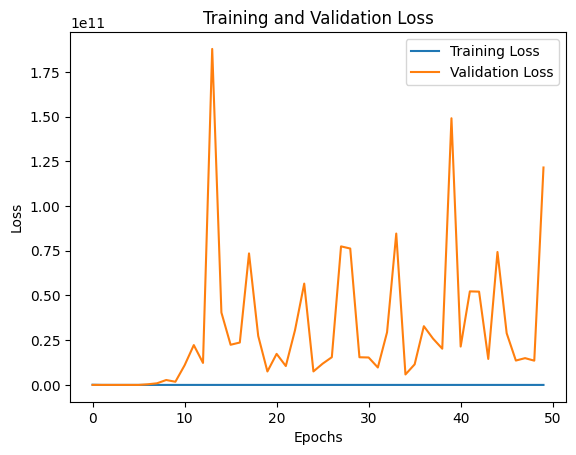

In [39]:
import matplotlib.pyplot as plt


# history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()


In [ ]:
nn_predictions = model.predict(X_val).flatten()  

# Recommendation sys

In [11]:
df_final.head()

,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Brand,Car_Type,High_Performance
0,2017,12000,Automatic,15944,Petrol,150.0,57.7,1.0,Ford,Hatchback,0
1,2018,14000,Manual,9083,Petrol,150.0,57.7,1.0,Ford,Hatchback,0
2,2017,13000,Manual,12456,Petrol,150.0,57.7,1.0,Ford,Hatchback,0
3,2019,17500,Manual,10460,Petrol,145.0,40.3,1.5,Ford,Hatchback,0
4,2019,16500,Automatic,1482,Petrol,145.0,48.7,1.0,Ford,Hatchback,0


In [12]:
from sklearn.metrics.pairwise import cosine_similarity
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler, OneHotEncoder


data = df_final

numeric_features = ['year', 'engineSize', 'mileage', 'tax', 'mpg', 'High_Performance']
categorical_features = ['Brand', 'fuelType', 'Car_Type', 'transmission']


numeric_imputer = SimpleImputer(strategy='median')  
data[numeric_features] = numeric_imputer.fit_transform(data[numeric_features])

categorical_imputer = SimpleImputer(strategy='most_frequent')  
data[categorical_features] = categorical_imputer.fit_transform(data[categorical_features])


scaler = StandardScaler()
data[numeric_features] = scaler.fit_transform(data[numeric_features])

encoder = OneHotEncoder()
encoded_categories = encoder.fit_transform(data[categorical_features]).toarray()
vehicle_features = np.hstack([data[numeric_features].values, encoded_categories])
    
# similarity_matrix = cosine_similarity(vehicle_features)
# similar_indices = np.argsort(-similarity_matrix[vehicle_id])[:5]
# recommendations = data.iloc[similar_indices[1:]]



In [ ]:
def compute_similarity_in_chunks(data, chunk_size = 500):
    n = data.shape[0]
    similarity_matrix = np.zeros((n,n))
    for i in range(0, n ,chunk_size):
        for j in range(0, n ,chunk_size):
            data_chunk_i  = data[i:i+chunk_size]
            data_chunk_j  = data[j:j+chunk_size]
            sim_chunk = cosine_similarity(data_chunk_i, data_chunk_j)
            similarity_matrix[i:i+chunk_size, j:j+chunk_size] = sim_chunk
    return similarity_matrix

chunk_size = 500
similarity_matrix = compute_similarity_in_chunks(vehicle_features, chunk_size)

In [ ]:
np.save('similarity_matrix.npy', similarity_matrix)